### Insurance Data Analysis

Problem Statement: 
An insurance agency, ABC Insurance, has a large dataset containing information about their policyholders and claims. They want to perform exploratory data analysis (EDA) on this dataset to gain insights that can help them make better business decisions and improve their operations. 

The agency wants to analyze the different body types and the environment that affect the premium. The disease's effect or the cost of treatment differs depending on the circumstances. For example, a smoker's medical insurance premium may be higher than that of a healthy person, because smokers are more likely to develop chronic diseases. The agency wants to analyze the data to research healthcare premium costs.

Objective: To analyze the dataset that will help to create a model that will predict the cost of medical insurance based on various input features

Domain: Healthcare

Dataset: insurance dataset (insurance.csv)

Dataset Description:

age	Age of the person  
sex	Female or Male  
BMI	BMI value to estimate an individual's health and fitness condition  
children	number of children (1,2,3,4, or 5)  
smoker	The person is a smoker or not  
region	Specifies the region (northeast, northwest, southeast, southwest)  
charges	the amount of insurance   


Steps to Be Followed:   
1.	Import libraries such as Pandas, matplotlib, NumPy, and seaborn and load the insurance dataset  
2.	Check the shape of the data along with the data types of the column  
3.	Check missing values in the dataset and find the appropriate measures to fill in the missing values  
4.	Explore the relationship between the feature and target column using a count plot of categorical columns and a scatter plot of numerical columns  
5.	Perform data visualization using plots of feature vs feature  
6.	Check if the number of premium charges for smokers or non-smokers is increasing as they are aging  
7.	After each step, specify the observations

## 1. Import libraries such as Pandas, matplotlib, NumPy, and seaborn and load the insurance dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('insurance.csv')

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Check the shape of the data along with the data types of the column and
## 3. Check missing values in the dataset and find the appropriate measures to fill in the missing values

In [19]:
print(data.shape)
print(data.info())

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [22]:
data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [25]:
print('Duplicated rows',data.duplicated().sum())

Duplicated rows 1


In [26]:
data.drop_duplicates(inplace=True)

In [27]:
print('Duplicated rows',data.duplicated().sum())

Duplicated rows 0


In [28]:
data.shape

(1337, 7)

In [53]:
# Converting the data into a Dataframe

df = pd.DataFrame(data)

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [53]:
# Target column - charges
# Numerical column - age, bmi, children , charges
# Categorical column - sex, smoker, region

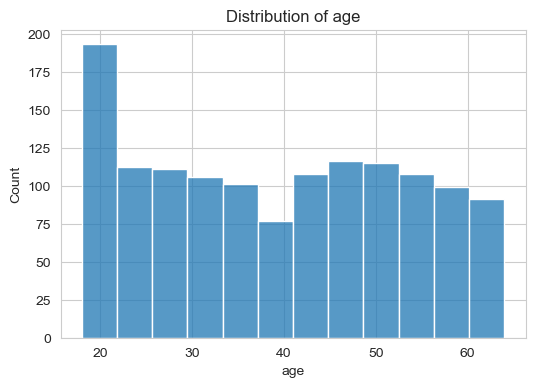

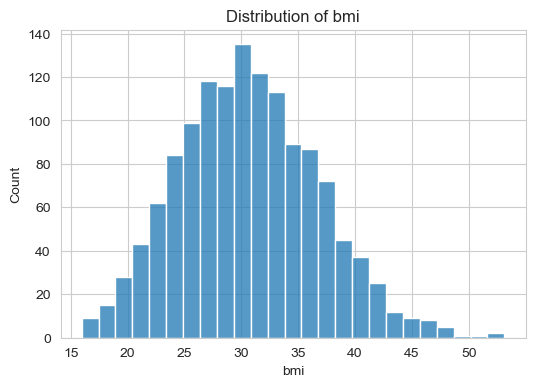

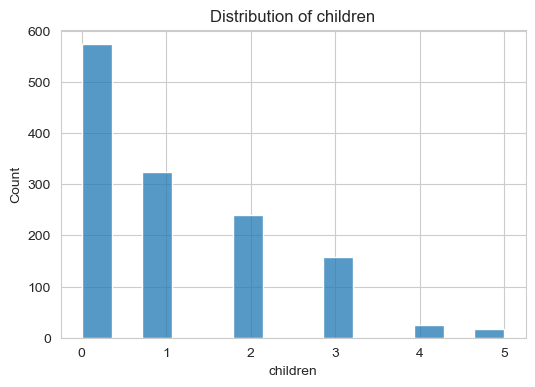

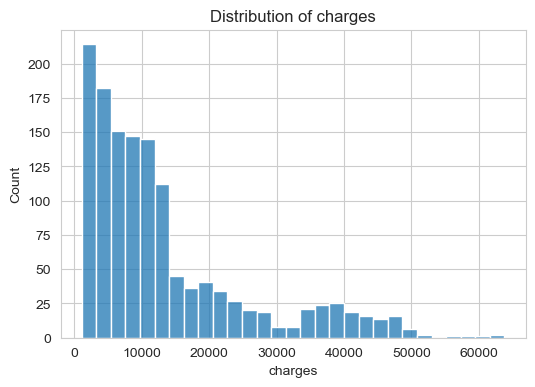

In [44]:
numeric_cols = ['age', 'bmi', 'children', 'charges']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.set_style('whitegrid')
    sns.histplot(data[col])
    plt.title(f'Distribution of {col}')
    plt.show()

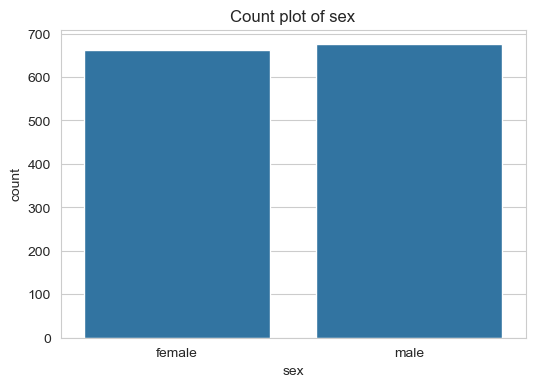

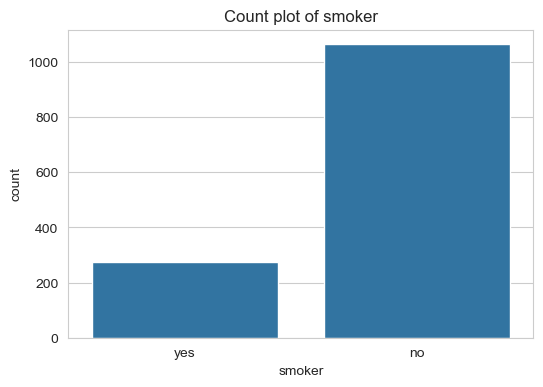

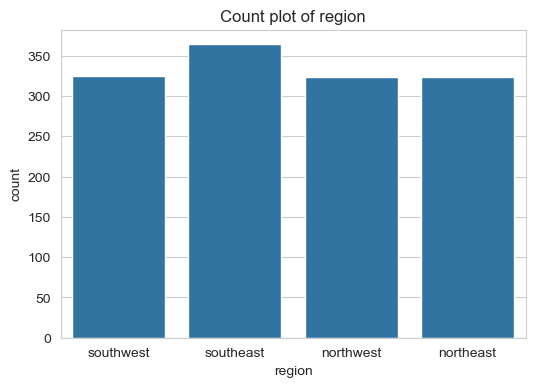

In [51]:
categorical_cols = ['sex', 'smoker', 'region']

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.set_style('whitegrid')
    sns.countplot(df, x = col)
    plt.title(f'Count plot of {col}')
    plt.show()

### 4. Explore the relationship between the feature and target column using a count plot of categorical columns and a scatter plot of numerical columns

### Boxplots and Violinplots for Categorical columns - sex, smoker, region

##### Boxplot - Insurance Charges Distribution by Smoking Status

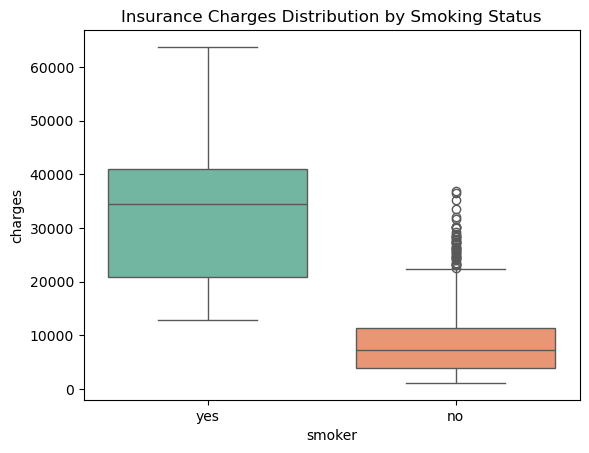

In [47]:
sns.boxplot(data = df, x = 'smoker', y = 'charges', hue = 'smoker', legend = False, palette = 'Set2')
plt.title('Insurance Charges Distribution by Smoking Status')
plt.show()

##### Boxplot - Insurance Charges Distribution by Sex

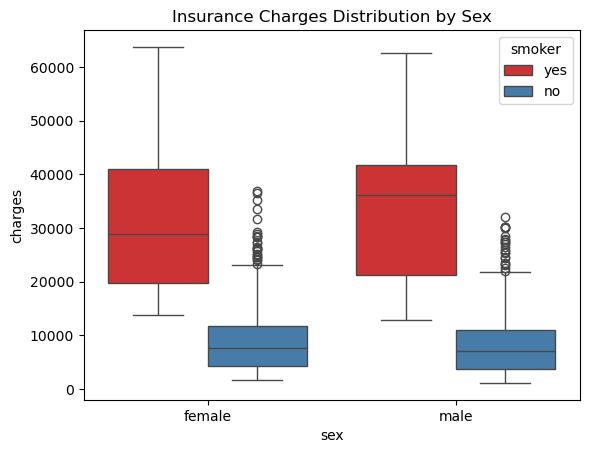

In [48]:
sns.boxplot(data = df, x = 'sex', y = 'charges', hue = 'smoker', palette = 'Set1')
plt.title('Insurance Charges Distribution by Sex')
plt.show()

##### Violinplot - Insurance Charges Distribution by Region

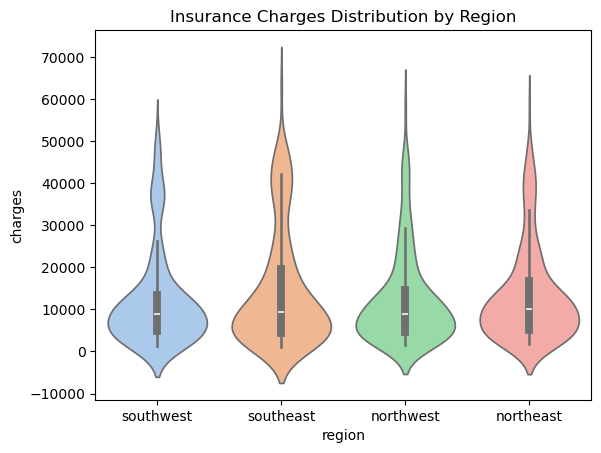

In [50]:
sns.violinplot(data = df, x = 'region', y = 'charges', hue = 'region', legend = False, palette = 'pastel')
plt.title('Insurance Charges Distribution by Region')
plt.show()

### Scatter plots for Numerical columns - age, bmi, children, charges

##### Scatter plot - Age vs Charges (Smokers colored)

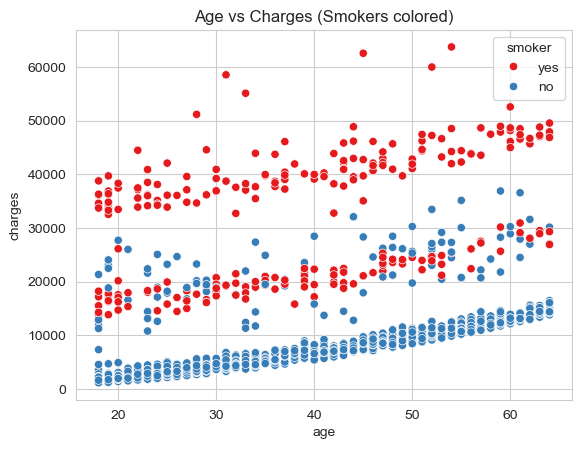

In [85]:
sns.scatterplot(data = df, x = 'age', y = 'charges', hue = 'smoker', palette = 'Set1')
plt.title('Age vs Charges (Smokers colored)')
plt.show()

##### Scatter plot - BMI vs Charges (Smokers colored)

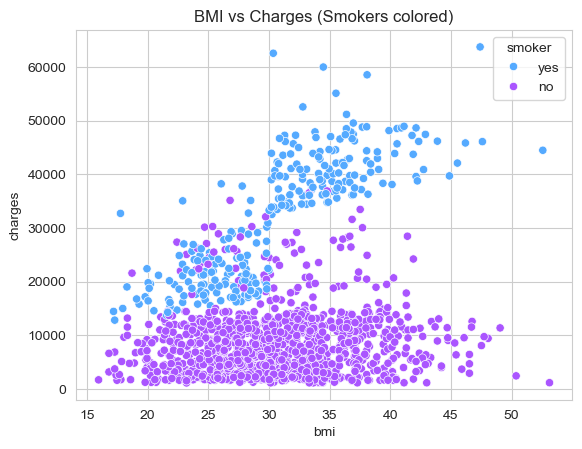

In [86]:
sns.scatterplot(data = df, x = 'bmi', y = 'charges', hue = 'smoker', palette = 'cool')
plt.title('BMI vs Charges (Smokers colored)')
plt.show()

##### Scatter plot - No of Children vs Charges (Smokers colored)

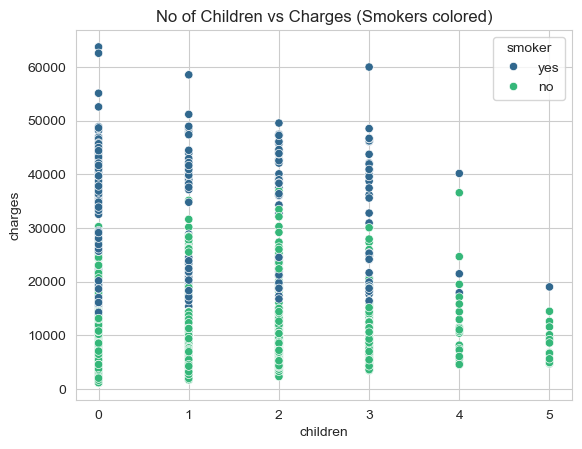

In [88]:
sns.scatterplot(data = df, x = 'children', y = 'charges', hue = 'smoker', palette = 'viridis')
plt.title('No of Children vs Charges (Smokers colored)')
plt.show()

## 5. Perform data visualization using plots of feature vs feature

##### Pairplot

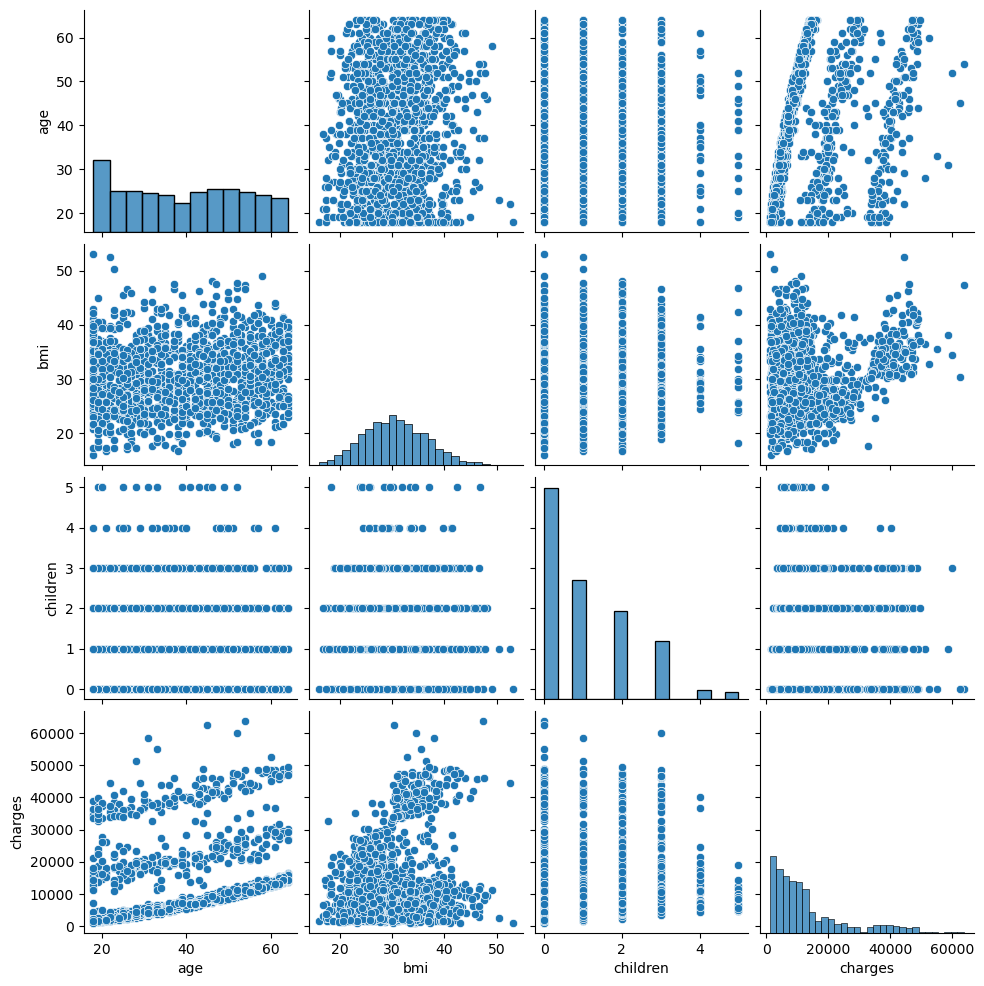

In [54]:
sns.pairplot(data = df)

##### Heatmap

<Axes: >

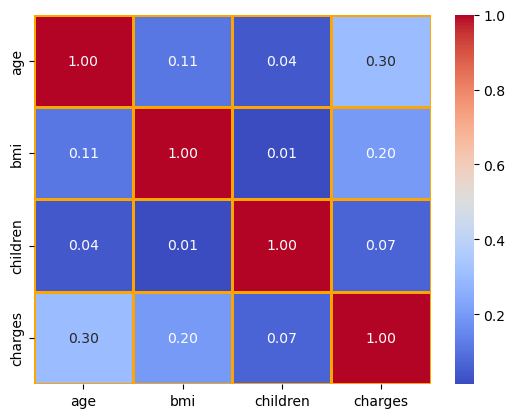

In [6]:
columns = ['age', 'bmi', 'children', 'charges']

sns.heatmap(data = df[columns].corr(), annot = True, fmt = '.2f', linewidths=2, linecolor='orange', cmap = 'coolwarm')

## 6.	Check if the number of premium charges for smokers or non-smokers is increasing as they are aging

<Figure size 1000x600 with 0 Axes>

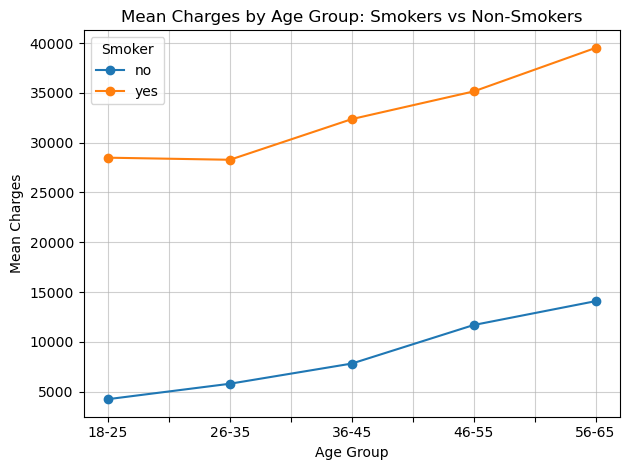

In [46]:
# 1. Create age bins
age_bins = [18, 25, 35, 45, 55, 65]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65']

df['age_bin'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=True)

# 2. Calculating the mean charges by age bin and smoking status
mean_charges_bin = (df.groupby(['age_bin', 'smoker'], observed=True)['charges'].mean().reset_index())

# 3. Pivot for line plotting
pivot_mean = mean_charges_bin.pivot(index='age_bin', columns='smoker', values='charges')

plt.figure(figsize=(10, 6))
pivot_mean.plot(marker='o')
plt.title('Mean Charges by Age Group: Smokers vs Non-Smokers')
plt.xlabel('Age Group')
plt.ylabel('Mean Charges')
plt.grid(True, alpha = 0.6)
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

### Final Observation -

After performing the EDA on the Insurance Dataset, it was observed that age, BMI and smoking status have a significant impact on the Insurance premium charges. Out of all factors Smoking status has the most impact on the Insurance premium charges. People who are smokers and have a higher age range have to pay a much higher Isurance premium due to their higher medical risk and treatment cost.

Smokers and non smokers have to pay increasing premium as the age increases but Smokers have a much higher steep as compared to Non smokers. Similarly BMI also has a moderate impact on the Insurancce charges. This shows us that bad lifetyle, along with smoking among poeple has a bad impact upon thier health also raising thier premium charges due to risks.

Other factors such as region, children, sex do not have much impact on the Insurance premium charges. Premium charges are mostly evenly spread among all reagions and sex too indicating that they do not play an important role in impacting the Insurance premium charges. Having more or less children does not create any health liability - so it does not impact the Insurance premium charges majorly.

These insights can help the ABC insurance company to better assess risk, design pricing strategies, focus on important factors and build predictive models for estimating medical insurance costs.